# Case Study 8: GAN — Digit Generation on MNIST
**Objective:** Implement a Deep Convolutional GAN (DCGAN) to generate handwritten digit images.
**Covers:** Generator–Discriminator setup, training behaviour, generated sample quality, adversarial learning explanation.

In [1]:
!pip install torch torchvision matplotlib numpy --quiet

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

LATENT_DIM = 100
IMG_SIZE   = 28
CHANNELS   = 1

Device: cuda


## 1. Load MNIST

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # normalize to [-1, 1] for tanh output
])
dataset    = datasets.MNIST('.', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2)
print(f'Dataset size: {len(dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 359kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.32MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]

Dataset size: 60000


## 2. Generator & Discriminator Setup

In [4]:
def weights_init(m):
    """Custom weight initialization (DCGAN paper recommendation)."""
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    """
    Input:  z ~ N(0,1) of shape (B, LATENT_DIM)
    Output: fake image of shape (B, 1, 28, 28) in range [-1, 1]
    """
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            # z → 7x7 feature map
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.Unflatten(1, (128, 7, 7)),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 7x7 → 14x14
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # 14x14 → 28x28
            nn.ConvTranspose2d(64, 1, 4, stride=2, padding=1),
            nn.Tanh()  # output in [-1, 1]
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    """
    Input:  image (B, 1, 28, 28)
    Output: scalar probability (B,) — real=1, fake=0
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 28x28 → 14x14
            nn.Conv2d(1, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 → 7x7
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

G = Generator(LATENT_DIM).to(device); G.apply(weights_init)
D = Discriminator().to(device);       D.apply(weights_init)

print(f'Generator params:     {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')

Generator params:     766,017
Discriminator params: 138,817


## 3. Training

In [5]:
criterion = nn.BCELoss()
opt_G     = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D     = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Fixed noise to track generator progress
fixed_noise = torch.randn(64, LATENT_DIM, device=device)

EPOCHS      = 30
g_losses, d_losses = [], []
d_real_accs, d_fake_accs = [], []
sample_grids = []  # save generated images every 10 epochs

for epoch in range(EPOCHS):
    g_loss_epoch = d_loss_epoch = 0
    d_real_epoch = d_fake_epoch = 0

    for real_imgs, _ in dataloader:
        B         = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        real_lbl  = torch.ones(B,  device=device)
        fake_lbl  = torch.zeros(B, device=device)

        # ── Train Discriminator ──────────────────────────────────────
        opt_D.zero_grad()
        # Real images → D should output 1
        d_real  = D(real_imgs)
        loss_d_real = criterion(d_real, real_lbl)
        # Fake images → D should output 0
        z        = torch.randn(B, LATENT_DIM, device=device)
        fake_imgs = G(z).detach()  # detach so G gradients not computed
        d_fake   = D(fake_imgs)
        loss_d_fake = criterion(d_fake, fake_lbl)
        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        opt_D.step()

        # ── Train Generator ───────────────────────────────────────────
        opt_G.zero_grad()
        z         = torch.randn(B, LATENT_DIM, device=device)
        fake_imgs = G(z)
        # Generator wants D to output 1 for fake images
        loss_g = criterion(D(fake_imgs), real_lbl)
        loss_g.backward()
        opt_G.step()

        g_loss_epoch += loss_g.item()
        d_loss_epoch += loss_d.item()
        d_real_epoch += d_real.mean().item()
        d_fake_epoch += d_fake.mean().item()

    n = len(dataloader)
    g_losses.append(g_loss_epoch / n)
    d_losses.append(d_loss_epoch / n)
    d_real_accs.append(d_real_epoch / n)
    d_fake_accs.append(d_fake_epoch / n)

    if (epoch+1) % 10 == 0:
        G.eval()
        with torch.no_grad():
            fake = G(fixed_noise).cpu()
        sample_grids.append((epoch+1, fake))
        G.train()
        print(f'Epoch {epoch+1}/{EPOCHS} | D loss: {d_losses[-1]:.4f} | G loss: {g_losses[-1]:.4f} | D(real): {d_real_accs[-1]:.3f} | D(fake): {d_fake_accs[-1]:.3f}')

Epoch 10/30 | D loss: 0.5412 | G loss: 1.9930 | D(real): 0.795 | D(fake): 0.205
Epoch 20/30 | D loss: 0.4914 | G loss: 2.2676 | D(real): 0.817 | D(fake): 0.182
Epoch 30/30 | D loss: 0.4742 | G loss: 2.3612 | D(real): 0.824 | D(fake): 0.176


## 4. Training Behaviour & Generated Sample Quality

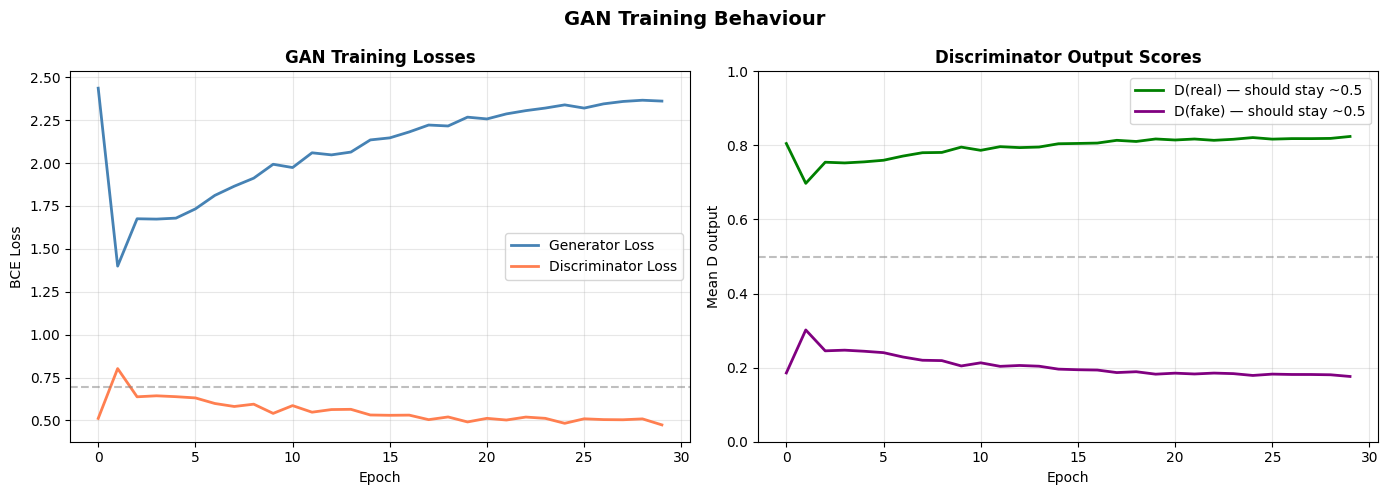

In [6]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(g_losses, label='Generator Loss',     color='steelblue', linewidth=2)
axes[0].plot(d_losses, label='Discriminator Loss', color='coral',     linewidth=2)
axes[0].set_title('GAN Training Losses', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.693, color='gray', linestyle='--', alpha=0.5, label='Ideal D loss (ln2≈0.693)')

axes[1].plot(d_real_accs, label='D(real) — should stay ~0.5', color='green',  linewidth=2)
axes[1].plot(d_fake_accs, label='D(fake) — should stay ~0.5', color='purple', linewidth=2)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Discriminator Output Scores', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean D output')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('GAN Training Behaviour', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_gan_training.png', dpi=150, bbox_inches='tight')
plt.show()

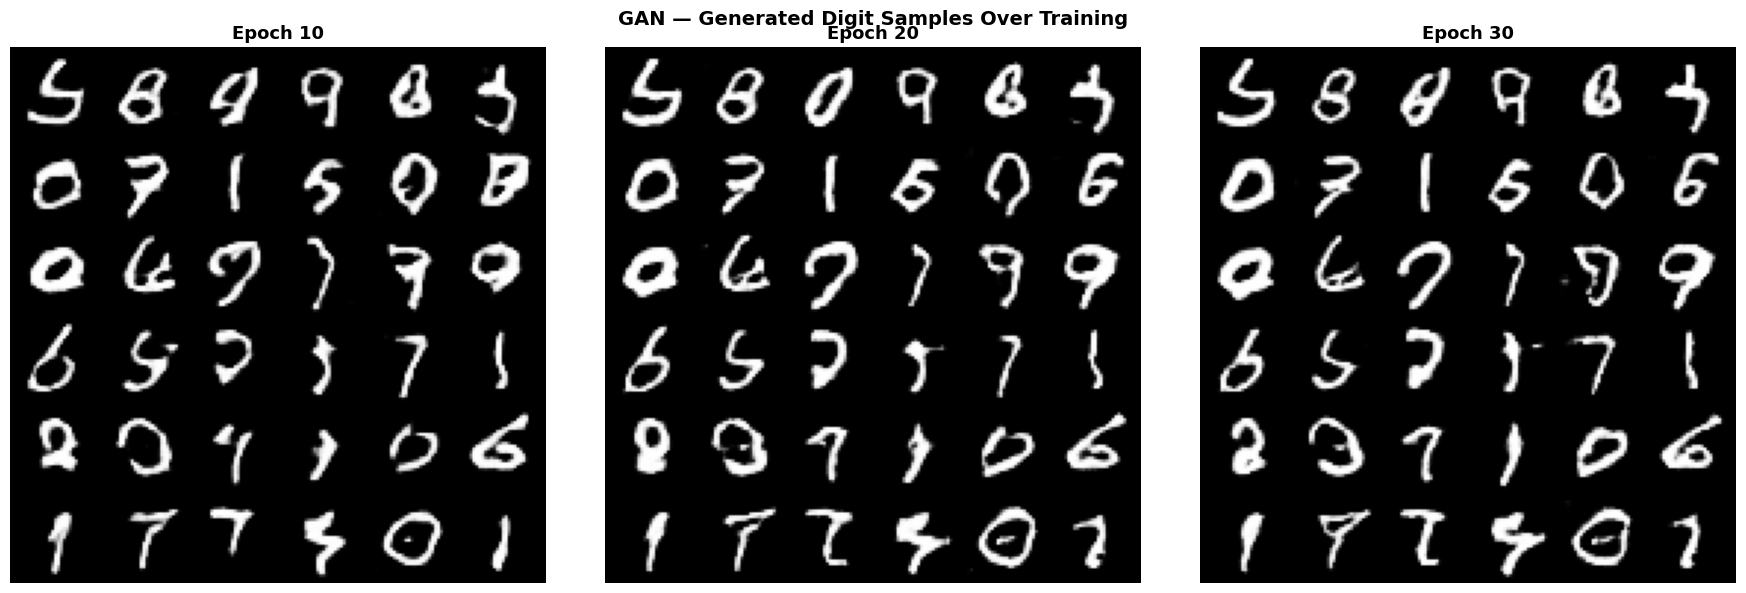

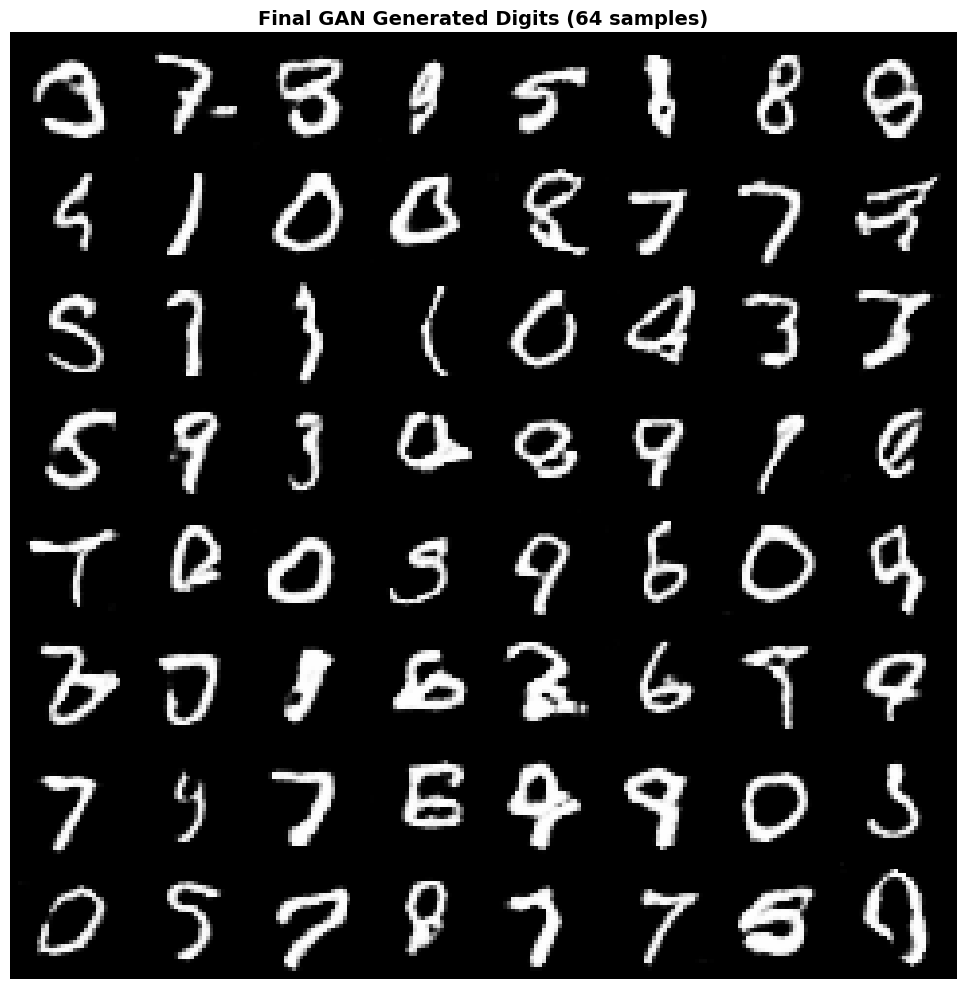

In [7]:
# Show generated samples at epoch 10, 20, 30
fig, axes = plt.subplots(1, len(sample_grids), figsize=(6*len(sample_grids), 6))
if len(sample_grids) == 1:
    axes = [axes]
for ax, (ep, fake) in zip(axes, sample_grids):
    grid = make_grid(fake[:36], nrow=6, normalize=True, value_range=(-1,1))
    ax.imshow(grid.permute(1,2,0), cmap='gray')
    ax.axis('off')
    ax.set_title(f'Epoch {ep}', fontsize=13, fontweight='bold')

plt.suptitle('GAN — Generated Digit Samples Over Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# Final grid of generated samples
G.eval()
with torch.no_grad():
    z    = torch.randn(64, LATENT_DIM, device=device)
    fake = G(z).cpu()
grid = make_grid(fake, nrow=8, normalize=True, value_range=(-1,1))
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1,2,0), cmap='gray')
plt.axis('off')
plt.title('Final GAN Generated Digits (64 samples)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_final_samples.png', dpi=150)
plt.show()

## 5. Explanation of Adversarial Learning

### The Adversarial Framework
A GAN consists of two networks locked in a **minimax game**:

| Network | Goal | Input | Output |
|---------|------|-------|--------|
| **Generator G** | Fool D into thinking fakes are real | Random noise z | Fake image |
| **Discriminator D** | Correctly classify real vs fake | Image | P(real) ∈ [0,1] |

### Loss Functions
```
D loss = -[log D(real) + log(1 - D(G(z)))]
G loss = -log D(G(z))   # G wants D(G(z)) → 1
```

### Training Behaviour — What to Watch
| Signal | Healthy | Problem |
|--------|---------|----------|
| D loss | Converges near ln(2) ≈ 0.693 | Drops to 0 → D too strong, G can't learn |
| G loss | Gradually decreasing | Explodes → mode collapse |
| D(real) | ~0.5 at equilibrium | Always 1.0 → D trivially wins |
| D(fake) | ~0.5 at equilibrium | Always 0.0 → G never fools D |

### Nash Equilibrium
The ideal outcome is when G generates samples indistinguishable from real data, and D outputs exactly 0.5 for all inputs (can't tell real from fake). In practice, training is unstable — solutions include label smoothing, spectral normalization, and Wasserstein loss (WGAN).